# EDA: Personality Type Prediction

**Project step 1 of 3:** `eda.ipynb` → `modeling.ipynb` → `app.py`

The data comes from the **Big Five (OCEAN) personality test**, published on Kaggle. Each row is one
person: their answers to **19 short statements** (1 = Disagree … 5 = Agree), their `age`, `gender`
and writing `hand`, and the `target`, the personality type we want to predict
(Moderate, Resilient, Overcontroller or Undercontroller).

This notebook explores the raw data, finds the problems in it, fixes them in **one place** and saves
the result for the modeling notebook:

1. **Setup:** load `data/data.csv` (downloaded automatically from the project Drive if it is missing)
2. **The target:** how the four personality types are distributed and how they answer
3. **Data quality checks:** answers outside 1–5, impossible ages, missing gender/hand, identical answers
4. **Cleaning:** apply all decisions in one cell and save **`data/data_clean.csv`**, the hand-off to `modeling.ipynb`
5. **Exploring the cleaned data:** answers per type, answer spread, OCEAN coverage, correlations, demographics
6. **Key findings** and what they mean for the modeling

> This notebook only **fixes** the data (wrong or impossible values).<br>
> The preprocessing **pipeline**
> (imputing, scaling, one-hot encoding) lives in `modeling.ipynb`, because it has to be learned on the
> training data only.

## 1. Setup and loading the data

The first cell installs two helper packages if they are missing (`gdown` downloads the dataset from
Google Drive, `ipywidgets` shows a progress bar), then downloads `data.csv` into the `data/` folder,
but only if the file is not there yet. If you already placed the file there by hand, as the README
describes, nothing is downloaded.

In [1]:
# Install the two helper packages only if they are missing
# (both are also listed in requirements.txt)
import subprocess
import sys
from pathlib import Path

for pkg in ["gdown", "ipywidgets"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "--quiet", pkg],
            check=True
        )

# Imports
import gdown
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
import textwrap

from IPython.display import HTML, display


# Where the data lives: data/data.csv (the same folder modeling.ipynb reads from)
FILE_ID = "1lgycXDQapixkoWFxIg48qaYcrNl6uSZM"

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
DATA_FILE = DATA_DIR / "data.csv"


# Progress bar for the download step
progress = widgets.IntProgress(
    value=0,
    min=0,
    max=100,
    description="Setup:",
    bar_style="info"
)

status = widgets.HTML(value="Starting setup...")
output = widgets.Output()

with output:
    display(progress, status)

display(output)


# Download the dataset from the project Drive, unless it is already there
progress.value = 20
status.value = "Checking dataset..."

if DATA_FILE.exists():
    progress.value = 100
    progress.bar_style = "success"
    status.value = "✓ Dataset already available."

else:
    progress.value = 40
    status.value = "Downloading dataset..."

    url = f"https://drive.google.com/uc?id={FILE_ID}"
    gdown.download(url, output=str(DATA_FILE), quiet=True)

    if not DATA_FILE.exists():
        raise FileNotFoundError(
            f"Download failed. File not found: {DATA_FILE}"
        )

    progress.value = 100
    progress.bar_style = "success"
    status.value = "✓ Download complete."

Output()

### Settings used in this notebook

- **Age rules:** a real age is between **13 and 100**. 13 is the youngest age in the data and also the
  lowest age the Streamlit app accepts. A value between **1918 and 2004** is read as a **birth year**
  and turned into an age.
- **Reference year 2017:** the codebook gives no survey year. The team assumed **2017** (the middle of
  2016–2018) to turn a birth year into an age: `age = 2017 − birth year`.
- **Colours:** one fixed colour per personality type, so every plot uses the same colours.

In [2]:
# --- Age rules -----------------------------------------------------------
MIN_AGE = 13              # youngest plausible age (also the lowest age the app accepts)
MAX_AGE = 100             # oldest plausible age
REFERENCE_YEAR = 2017     # assumed survey year, used to turn a birth year into an age
MIN_BIRTH_YEAR = REFERENCE_YEAR - MAX_AGE + 1   # 1918 -> age 99
MAX_BIRTH_YEAR = REFERENCE_YEAR - MIN_AGE       # 2004 -> age 13

# --- The five OCEAN traits (column names start with their letter) ---------
TRAITS = {
    "O": "Openness to Experience",
    "C": "Conscientiousness",
    "E": "Extraversion",
    "A": "Agreeableness",
    "N": "Neuroticism"
}

ocean_order = list(TRAITS.values())

# --- One fixed colour per personality type, used in every plot -------------
TARGET_COLORS = {
    "Resilient":        "#e07a5f",  # muted terracotta/coral
    "Overcontroller":   "#81b29a",  # sage/mint green
    "Undercontroller":  "#f2cc8f",  # warm ochre yellow
    "Moderate":         "#2b5c6f"   # petroleum blue (same as the primary theme colour)
}

target_order = list(TARGET_COLORS.keys())

# --- Colours for titles, info boxes and heatmaps -----------------------------
THEME = {
    "primary":          "#2b5c6f",  # Main petroleum blue for titles & headers
    "success_bg":       "#edf7f4",  # Soft mint/sage background
    "success_border":   "#81b29a",  # Sage/mint green border (matches Overcontroller)
    "danger_bg":        "#fdf2f2",  # Soft coral/red background
    "danger_border":    "#e07a5f",  # Terracotta/coral border (matches Resilient)
    "palette":          "Blues"
}

### Load the data

One row is one person. `question_columns` lists the 19 statements in codebook order.

In [3]:
# Load the raw data and show more rows/columns in tables
df = pd.read_csv(DATA_FILE)

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)

question_columns = [
    'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10',
    'E1', 'E3', 'E4', 'E5', 'E7', 'E9', 'E10', 'C4', 'A4'
]

display(HTML(f"""
<div style="display:inline-block; padding:10px 14px; margin:8px 0; 
            background:{THEME['success_bg']}; border-left:4px solid {THEME['success_border']}; 
            border-radius:5px; font-size:14px;">
    <b>Initial data:</b> {len(df):,} rows · {df.shape[1]} columns
</div>
"""))

### 1.1 First look: structure, data types and missing values

The tables below show the first and last rows, summary statistics, the data type and number of
missing values per column, and how often each value appears in `age`, `gender`, `hand` and `target`.

In [4]:
display(HTML("<h4 style='margin:16px 0 8px;'>First 5 rows (head)</h4>"))
display(df.head())

display(HTML("<h4 style='margin:16px 0 8px;'>Last 5 rows (tail)</h4>"))
display(df.tail())

display(HTML("<h4 style='margin:16px 0 8px;'>Summary statistics (numerical columns)</h4>"))
display(df.describe())

column_info = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Non-null": df.notna().sum(),
    "Missing": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(2)
})
column_info["Status"] = np.where(column_info["Missing"] > 0, "⚠ Missing values", "✓ Complete")

display(HTML("<h4 style='margin:16px 0 8px;'>Column overview & missing values</h4>"))
display(column_info)

display(HTML("<h4 style='margin:16px 0 8px;'>Categorical & key demographic distributions</h4>"))
html = '<div style="display:flex; flex-wrap:wrap; gap:18px; align-items:flex-start;">'
for col in ["age", "gender", "hand", "target"]:
    table = df[col].value_counts(dropna=False).sort_index().to_frame("Count").to_html()
    html += f"""
    <div style="min-width:150px; padding:10px; background:#f8fafc; border:1px solid #d9e2ec; border-radius:6px;">
        <div style="margin-bottom:8px; color:{THEME['primary']}; font-weight:700;">{col}</div>
        {table}
    </div>
    """
html += '</div>'
display(HTML(html))

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9,gender,hand,target
0,1,1,1,1,1,1,2,1,5,5,5,5,4,2,53,1,4,5,1,5,Male,Right,Resilient
1,4,2,3,2,2,4,4,3,3,3,3,2,1,3,46,2,2,4,5,1,Female,Right,Moderate
2,5,5,5,5,5,5,5,5,1,1,5,5,1,4,14,1,5,5,1,5,Female,Right,Moderate
3,5,5,5,5,4,5,4,4,2,4,3,2,3,4,19,5,2,4,5,4,Female,Right,Overcontroller
4,3,3,3,3,3,4,3,3,3,3,3,4,3,3,25,3,3,5,5,3,Female,Right,Moderate


,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9,gender,hand,target
19714,5,4,4,5,4,4,5,4,3,3,4,3,1,5,15,3,1,5,5,1,Female,Right,Overcontroller
19715,2,2,2,2,2,2,2,3,2,4,2,4,2,3,37,2,2,4,4,4,Female,Right,Resilient
19716,5,5,5,5,5,5,5,5,4,1,5,1,1,5,16,5,2,2,5,1,Male,Right,Overcontroller
19717,4,4,4,4,4,4,5,4,2,3,2,2,1,3,16,2,1,4,5,4,Male,Right,Overcontroller
19718,3,3,4,5,2,4,5,3,1,2,3,2,3,5,35,4,2,3,4,2,Male,Right,Overcontroller


,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9
count,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,1.971900e+04,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000
mean,2.980374,2.803235,3.151935,3.262082,3.135250,2.833764,3.842690,2.951722,3.416755,3.234596,3.432223,2.756276,2.867285,3.152036,5.076703e+04,2.654242,2.628937,4.030073,3.585324,3.094275
std,1.320437,1.350648,1.299910,1.308169,1.298573,1.313036,1.138854,1.272889,1.236820,1.177018,1.282003,1.220964,1.431814,1.222822,7.121272e+06,1.243191,1.232565,1.045403,1.304571,1.396490
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.300000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.800000e+01,2.000000,2.000000,4.000000,3.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,2.200000e+01,3.000000,3.000000,4.000000,4.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,3.100000e+01,4.000000,4.000000,5.000000,5.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000e+09,5.000000,5.000000,5.000000,5.000000,5.000000


,Data type,Non-null,Missing,Missing (%),Status
N6,int64,19719,0,0.00,✓ Complete
N8,int64,19719,0,0.00,✓ Complete
N7,int64,19719,0,0.00,✓ Complete
N1,int64,19719,0,0.00,✓ Complete
N9,int64,19719,0,0.00,✓ Complete
N10,int64,19719,0,0.00,✓ Complete
N3,int64,19719,0,0.00,✓ Complete
N5,int64,19719,0,0.00,✓ Complete
E3,int64,19719,0,0.00,✓ Complete
N2,int64,19719,0,0.00,✓ Complete


,Count
age,
13,238
14,475
15,743
16,1148
17,1370
18,1523
19,1259
20,1231
21,1216


**What we see:**

- **19,719 rows × 23 columns.** The 19 question columns and `age` are whole numbers. `gender`,
  `hand` and `target` are text.
- **Missing values only in two columns:** `gender` (24) and `hand` (100). Everything else is complete.
- **Two warning signs in the summary statistics:** the question columns have a **minimum of 0**,
  although the scale is 1–5, and `age` has a **maximum of 999,999,999**. Section 3 looks at both.
- The columns are not in codebook order (`N6, N8, N7, …`), and `age` sits between the question
  columns. We keep this order on purpose, because the model is trained on exactly these columns.

## 2. The target: what we predict

**Left:** how many people belong to each personality type.
**Right:** the average answer (1–5) to every question per type. This is the kind of signal the model
learns from. Both plots use the raw data, before cleaning (the cleaning in section 4 removes only
0.66% of the rows, so the picture stays the same).

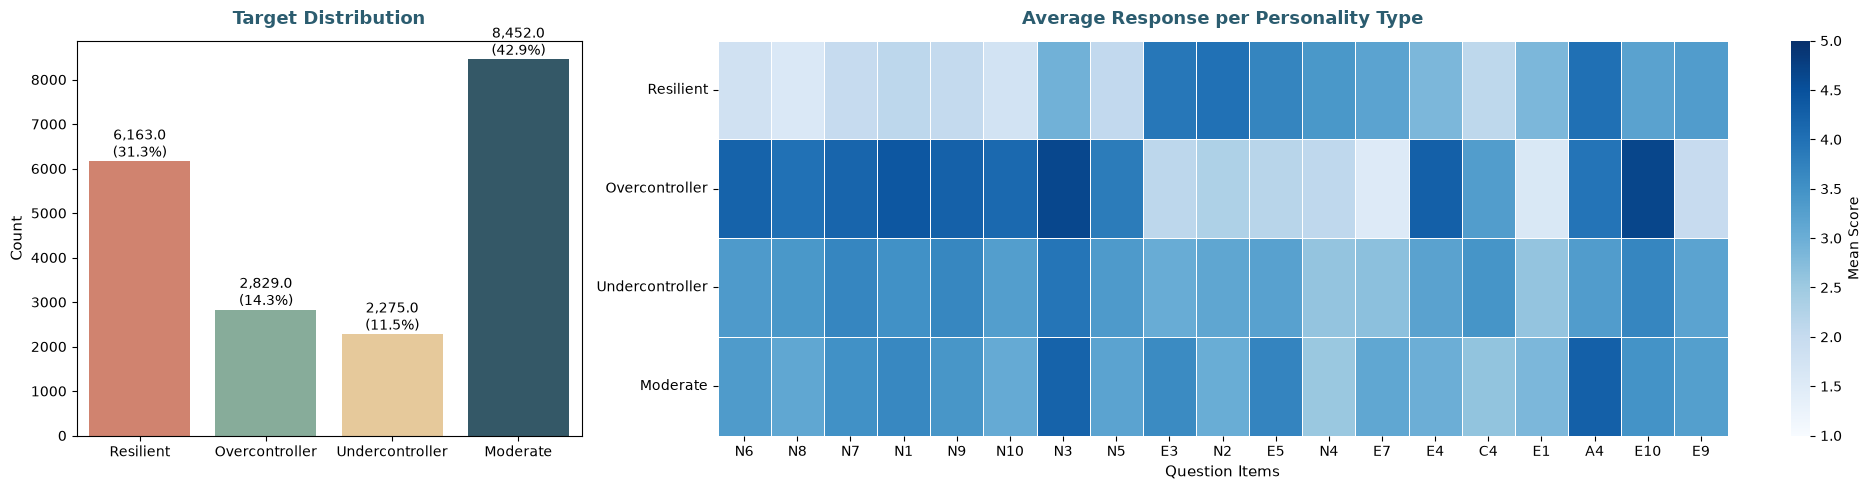

In [5]:
# The 19 question columns: every numeric column except the demographics and the target
item_cols = [
    c for c in df.columns
    if c not in ["age", "gender", "hand", "target"]
    and pd.api.types.is_numeric_dtype(df[c])
]

# The personality types in the data, in the fixed TARGET_COLORS order
target_order = [
    target for target in TARGET_COLORS
    if target in df["target"].dropna().unique()
]

# Average answer per question and type, in the same order as the bar chart
heatmap_data = (
    df.groupby("target", observed=True)[item_cols]
      .mean()
      .reindex(target_order)
)

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(20, 5),
    gridspec_kw={"width_ratios": [1, 2.5]}
)

# 1. Left: how many people per personality type
total = len(df)

sns.countplot(
    data=df,
    x="target",
    hue="target",
    order=target_order,
    hue_order=target_order,
    palette=TARGET_COLORS,
    legend=False,
    ax=ax1
)

for container in ax1.containers:
    ax1.bar_label(
        container,
        labels=[
            f"{bar.get_height():,}\n({bar.get_height() / total:.1%})"
            if bar.get_height() > 0 else ""
            for bar in container
        ]
    )

ax1.set_title(
    "Target Distribution",
    fontsize=13,
    pad=12,
    color=THEME["primary"],
    weight="bold"
)
ax1.set_xlabel("")
ax1.set_ylabel("Count", fontsize=11)

# 2. Right: average answer to each question per personality type
sns.heatmap(
    heatmap_data,
    cmap=THEME["palette"],  # "Blues"
    vmin=1,
    vmax=5,
    ax=ax2,
    linewidths=0.5,
    cbar_kws={"label": "Mean Score"}
)

ax2.set_title(
    "Average Response per Personality Type",
    fontsize=13,
    pad=12,
    color=THEME["primary"],
    weight="bold"
)
ax2.set_xlabel("Question Items", fontsize=11)
ax2.set_ylabel("")

plt.tight_layout()
plt.show()

**Interpretation:**

- **The classes are imbalanced:** Moderate ≈ 43%, Resilient ≈ 31%, Overcontroller ≈ 14%,
  Undercontroller ≈ 12%. A "model" that always answers *Moderate* would already be right 43% of the
  time while learning nothing. That is why `modeling.ipynb` compares models with **macro F1**, which
  counts every type equally, and not with accuracy.
- **Resilient** people answer the Neuroticism statements (N…) very low (about 1.8 on "I get upset
  easily" and 1.6 on "I have frequent mood swings") and agree with "I am relaxed most of the time" (≈ 4).
- **Overcontrollers** are the mirror image: the highest Neuroticism answers (≈ 3.8–4.7) and the lowest
  Extraversion answers ("I am the life of the party" ≈ 1.6, "I talk to a lot of different people at
  parties" ≈ 1.5), while they agree with "I keep in the background" and "I am quiet around strangers".
- **Undercontrollers** stand out on only two statements: they agree most with "I make a mess of
  things" (C4) and agree least with "I sympathize with others' feelings" (A4). On all other questions
  they look much like Moderate. That makes them the hardest type to recognise (see section 5.3).
- **Moderate** sits in the middle on almost every question.

## 3. Data quality checks

The pipeline in `modeling.ipynb` can fill **missing** values, but it cannot tell that a value is
**wrong** (an age of 999,999,999 is not missing, it is impossible). So we look for wrong values here,
before any modeling.

### 3.1 Answers outside the 1–5 scale

Every answer should be between 1 (Disagree) and 5 (Agree). The summary below shows the lowest and
highest answer per question.

In [6]:
df[item_cols].describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
N6,2.98,1.32,0.0,5.0
N8,2.80,1.35,0.0,5.0
N7,3.15,1.30,0.0,5.0
N1,3.26,1.31,0.0,5.0
N9,3.14,1.30,0.0,5.0
N10,2.83,1.31,0.0,5.0
N3,3.84,1.14,0.0,5.0
N5,2.95,1.27,0.0,5.0
E3,3.42,1.24,0.0,5.0
N2,3.23,1.18,0.0,5.0


In [7]:
# True wherever an answer is below 1 or above 5
out_of_range = (df[item_cols] < 1) | (df[item_cols] > 5)
display(HTML(f"""
<div style="display:inline-block; padding:10px 14px; margin:8px 0;
            background:{THEME['danger_bg']}; border-left:4px solid {THEME['danger_border']};
            border-radius:5px; font-size:14px;">
    <b>Answers outside 1–5:</b> {out_of_range.sum().sum():,}<br>
    <b>Rows affected:</b> {out_of_range.any(axis=1).sum():,}
</div>
"""))
df[out_of_range.any(axis=1)]

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9,gender,hand,target
19064,0,0,0,0,0,0,0,0,0,0,0,0,0,0,52,0,0,0,0,0,Female,Right,Resilient


**Result:** all 19 values outside the scale come from **one single row** (index 19064): this person
has a `0` in every question. `0` is not on the 1–5 scale (in the original Kaggle data it means
"not answered"), so the row carries no usable answers and is **removed** in section 4. All other
answers are valid.

### 3.2 Age: impossible values and birth years

The summary statistics showed a maximum age of 999,999,999. The cell below sorts every age above 100
into three groups.

In [19]:
age_raw = df["age"]

too_high    = age_raw > MAX_AGE                                        # every age above 100
birth_years = age_raw.between(MIN_BIRTH_YEAR, MAX_BIRTH_YEAR)          # 1918-2004: a birth year typed in
three_digit = age_raw.between(MAX_AGE + 1, 999)                        # 101-999: probably a typo
nonsense    = too_high & ~birth_years & ~three_digit                   # everything else

display(HTML(f"""
<div style="max-width:700px; padding:12px 14px; margin:8px 0;
            background:#f8fafc; border-left:4px solid {THEME['primary']};
            border-radius:5px; font-size:14px; line-height:1.6;">
    <b>Age range</b><br>
    Lowest age: {age_raw.min():,} · Highest age: {age_raw.max():,}<br>
    People under 16: {(age_raw < 16).sum():,}<hr style="border:0; border-top:1px solid #d9e2ec;">
    <b>Ages above 100:</b> {too_high.sum():,}<br>
    Birth years: {birth_years.sum():,} (from {age_raw[birth_years].min()} to {age_raw[birth_years].max()})<br>
    Three-digit ages: {three_digit.sum():,} ({sorted(age_raw[three_digit].tolist())})<br>
    Other impossible values: {nonsense.sum():,} ({[f'{value:,}' for value in sorted(age_raw[nonsense])]})
</div>
"""))

**Result:**

- **83 ages are above 100.** **73** of them look like **birth years** (1961–2000): these people
  typed in the year they were born instead of their age. **8** are three-digit ages (118 to 266),
  probably typos. **2** are nonsense (412,434 and 999,999,999).
- The **lowest age is 13**, so there are no impossible low ages. About 1,450 people are under 16.
  That is young but plausible for an online personality test, so these rows stay.

**Decision:** birth years are **converted into ages** (`age = 2017 − birth year`, which gives ages
between 17 and 56), so these people's answers are not lost. The three-digit and nonsense ages cannot
be fixed reliably, so those rows are **removed** in section 4.

*Why not let the pipeline handle it?* The pipeline's imputer only fills **missing** values. These ages
are not missing, they are wrong, and values like 999,999,999 would also distort the scaling of `age`
for everyone else.

### 3.3 Gender and hand: missing categories

How often each category appears, including missing values (`NaN`).

In [9]:
for col in ["gender", "hand"]:
    counts_html = df[col].value_counts(dropna=False).to_frame("Count").to_html()
    display(HTML(f"""
    <div style="display:inline-block; vertical-align:top; min-width:180px;
                padding:10px 14px; margin:8px 10px 8px 0; background:#f8fafc;
                border-left:4px solid {THEME['primary']}; border-radius:5px;">
        <b style="color:{THEME['primary']};">{col.title()}</b><br>
        {counts_html}
    </div>
    """))

missing_both = df["gender"].isna() & df["hand"].isna()
missing_any = df["gender"].isna() | df["hand"].isna()
display(HTML(f"""
<div style="display:inline-block; padding:10px 14px; margin:8px 0;
            background:{THEME['danger_bg']}; border-left:4px solid {THEME['danger_border']};
            border-radius:5px; font-size:14px;">
    <b>Rows missing gender or hand:</b> {missing_any.sum():,}<br>
    <b>Rows missing both:</b> {missing_both.sum():,}
</div>
"""))

,Count
gender,
Female,11985
Male,7608
Other,102
NaN,24


,Count
hand,
Right,17424
Left,1724
Both,471
NaN,100


**Result:** `gender` is missing 24 times and `hand` 100 times. That is 124 empty cells in
**120 rows** (4 people are missing both). There are no other placeholder values such as `0` or
`"none"`.

**Decision:** these 120 rows (0.6% of the data) are **removed** rather than filled in, so the model
only learns from answers people actually gave. The imputer in the `modeling.ipynb` pipeline still
protects the app, should a value ever be missing there.

### 3.4 Identical answers and duplicate rows

Two more things that can point to careless or repeated submissions: people who gave the **same
answer to all 19 statements**, and rows that appear **more than once**.

In [10]:
# Same answer to every one of the 19 statements ("straight-lining")
same_answer = df[item_cols].nunique(axis=1).eq(1)
same_answer_counts = df.loc[same_answer, item_cols[0]].value_counts().sort_index().to_dict()
same_answer_counts_text = " · ".join(
    f"Answer {answer}: {count}"
    for answer, count in same_answer_counts.items()
)

# Rows that appear more than once (all 23 columns identical)
duplicates = df.duplicated(keep=False)
display(HTML(f"""
<div style="display:inline-block; padding:10px 14px; margin:8px 0;
            background:#f8fafc; border-left:4px solid {THEME['primary']};
            border-radius:5px; font-size:14px; line-height:1.6;">
    <b>Same answer to all 19 statements:</b> {same_answer.sum():,}<br>
    {same_answer_counts_text}<hr style="border:0; border-top:1px solid #d9e2ec;">
    <b>Rows appearing more than once:</b> {duplicates.sum():,}
    ({df.duplicated().sum():,} extra copies)
</div>
"""))
display(df[duplicates].sort_values(list(df.columns)))

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9,gender,hand,target
7127,5,5,5,5,5,5,5,5,5,5,5,5,5,5,18,5,5,5,5,5,Male,Right,Moderate
16591,5,5,5,5,5,5,5,5,5,5,5,5,5,5,18,5,5,5,5,5,Male,Right,Moderate
2793,5,5,5,5,5,5,5,5,5,5,5,5,5,5,21,5,5,5,5,5,Male,Right,Moderate
13093,5,5,5,5,5,5,5,5,5,5,5,5,5,5,21,5,5,5,5,5,Male,Right,Moderate
11342,5,5,5,5,5,5,5,5,5,5,5,5,5,5,23,5,5,5,5,5,Male,Right,Moderate
17685,5,5,5,5,5,5,5,5,5,5,5,5,5,5,23,5,5,5,5,5,Male,Right,Moderate


**Result:**

- **28 people** gave the same answer to every statement: 11 times all 5s, 8 times all 1s, 5 times
  all 3s, 3 times all 2s, plus the one row of 0s from section 3.1. Several statements are
  reverse-worded (for example "I get stressed out easily" vs. "I am relaxed most of the time"), so
  agreeing or disagreeing with *all* of them contradicts itself. These answers are suspicious.
- **3 rows appear twice.** All of them are such all-5 answers with the same age, gender and hand,
  most likely the same person submitting twice.

**Decision:** the team **keeps** these rows (only the all-0 row is removed, see 3.1). Together they
are about 0.1% of the data, far too few to change what the model learns, and a person who answers
"3 = Neutral" to everything is not necessarily wrong. A stricter version that deletes them was tried
in `JT_EDA_Personality_Type_prediction.ipynb`.

## 4. Cleaning: all decisions in one place

Based on section 3, a row is **removed** if:

| Step | Rule | Why |
|---|---|---|
| 1 | `age` is missing | no age to work with (turns out to be 0 rows) |
| 2 | `age` is a three-digit number (101–999) | probably a typo, cannot be fixed reliably |
| 3 | `age` is otherwise impossible (e.g. 999,999,999) | neither a real age nor a birth year |
| 4 | `gender` is missing or `0` | small number of rows, better removed than guessed |
| 5 | `hand` is missing or `0` | same as gender |
| 6 | a question has the answer `0` | outside the 1–5 scale ("not answered") |

And **kept and fixed**:

- **Birth years (1918–2004)** are converted into ages with `age = 2017 − birth year`.
- **Identical-answer and duplicate rows** are kept (see 3.4).

The steps run in this order, and every row is counted only in the **first** step that removes it.
The column order is **not** changed, because `modeling.ipynb` and the saved model expect exactly the
same columns, in the same order, as `data.csv`.

In [11]:
# --- One True/False flag per row for every cleaning rule -------------------------

# Variables from the age check above are reused here.
missing_age = age_raw.isna()
valid_age = age_raw.between(MIN_AGE, MAX_AGE)

birth_year = birth_years
three_digit_age = three_digit

# Includes values below MIN_AGE and values above 100 that are not birth years.
invalid_age = ~(valid_age | birth_year) & ~missing_age

# Turn birth years into ages, using the assumed survey year.
age_clean = age_raw.copy()
age_clean.loc[birth_year] = (
    REFERENCE_YEAR - age_raw.loc[birth_year]
)


def missing_or_zero(series):
    """True where a text column is empty, NaN, 0 or a placeholder such as 'none'."""
    normalized = series.astype("string").str.strip().str.lower()
    return series.isna() | normalized.isin({"0", "none", "null", "nan", ""})


missing_gender = missing_or_zero(df["gender"])
missing_hand = missing_or_zero(df["hand"])

# A 0 in at least one of the 19 question columns
question_zero = (df[question_columns] == 0).any(axis=1)

display(HTML(f"""
<div style="display:inline-block; padding:10px 14px; margin:8px 0;
            background:{THEME['success_bg']};
            border-left:4px solid {THEME['success_border']};
            border-radius:5px; font-size:14px;">
    <b>Birth years found and converted:</b> {birth_year.sum():,}
</div>
"""))

In [20]:
# Apply the rules step by step and track how many rows each step removes
df_work = df.copy()
df_work["age"] = age_clean          # ages with the birth years already converted

total_rows = len(df_work)
keep = pd.Series(True, index=df_work.index)   # starts with every row kept

steps = [
    ("age missing", missing_age),
    ("age three-digit", three_digit_age),
    ("age otherwise invalid", invalid_age),
    ("gender missing or 0", missing_gender),
    ("hand missing or 0", missing_hand),
    ("0 in question items", question_zero),
]

results = []
for name, criterion in steps:
    removed_now = keep & criterion          # rows this step removes (not removed by an earlier step)
    removed_count = removed_now.sum()
    keep &= ~criterion

    remaining = keep.sum()
    removed_pct = removed_count / total_rows * 100
    cumulative_removed = total_rows - remaining
    cumulative_pct = cumulative_removed / total_rows * 100

    results.append({
        "Step": name,
        "Removed in this step": removed_count,
        "Removed (%)": round(removed_pct, 3),
        "Remaining rows": remaining,
        "Cumulative removed": cumulative_removed,
        "Cumulative data loss (%)": round(cumulative_pct, 3),
    })

df_clean = df_work.loc[keep].copy()
df_clean["age"] = df_clean["age"].astype("Int64")   # whole numbers again after the conversion

# The column order stays exactly as in data.csv: the model in modeling.ipynb is trained on
# these columns in this order, and the app and the example row in modeling.ipynb rely on it.

loss_table = pd.DataFrame(results)
display(loss_table)

rows_deleted = len(df) - len(df_clean)
display(HTML(f"""
<div style="display:inline-block; padding:10px 14px; margin:8px 0; 
            background:{THEME['danger_bg']}; border-left:4px solid {THEME['danger_border']}; 
            border-radius:5px; font-size:14px;">
    <b>Initial data:</b> {len(df):,} rows · {df.shape[1]} columns<br>
    <b>Cleaned data:</b> {len(df_clean):,} rows · {df_clean.shape[1]} columns<br>
    <b>Deleted data:</b> {rows_deleted:,} rows ({rows_deleted / len(df) * 100:.3f} %)
</div>
"""))

# Save the cleaned data: this file is the input of modeling.ipynb
df_clean.to_csv(DATA_DIR / "data_clean.csv", index=False)
display(HTML(f"""
<div style="display:inline-block; padding:10px 14px; margin:8px 0;
            background:{THEME['success_bg']}; border-left:4px solid {THEME['success_border']};
            border-radius:5px; font-size:14px;">
    ✓ Cleaned dataset saved: <b>{DATA_DIR / 'data_clean.csv'}</b>
</div>
"""))

,Step,Removed in this step,Removed (%),Remaining rows,Cumulative removed,Cumulative data loss (%)
0,age missing,0,0.000,19719,0,0.000
1,age three-digit,8,0.041,19711,8,0.041
2,age otherwise invalid,2,0.010,19709,10,0.051
3,gender missing or 0,24,0.122,19685,34,0.172
4,hand missing or 0,96,0.487,19589,130,0.659
5,0 in question items,1,0.005,19588,131,0.664


**Result:** 131 rows (0.66%) are removed: 8 three-digit ages, 2 impossible ages, 24 rows without
gender, 96 more without hand (the 4 rows missing both were already removed in the gender step) and
the 1 row of zeros. **19,588 rows** remain. 71 birth years were converted into ages (the other 2 of
the 73 belonged to rows that were removed for a missing gender or hand).

### Check the saved file

Reading the file back confirms that it is what `modeling.ipynb` expects: no missing values, all
answers between 1 and 5, ages between 13 and 100, the same columns in the same order as `data.csv`,
and the same class balance as before cleaning.

In [13]:
check = pd.read_csv(DATA_DIR / "data_clean.csv")

display(HTML(f"""
<div style="display:inline-block; padding:12px 14px; margin:8px 0;
            background:{THEME['success_bg']}; border-left:4px solid {THEME['success_border']};
            border-radius:5px; font-size:14px; line-height:1.6;">
    <b>Saved-file validation</b><br>
    Rows, columns: {check.shape}<br>
    Missing values: {int(check.isna().sum().sum()):,}<br>
    All answers between 1 and 5: {bool(check[item_cols].isin([1, 2, 3, 4, 5]).all().all())}<br>
    Ages between: {check['age'].min()} and {check['age'].max()}<br>
    Same columns/order as data.csv: {list(check.columns) == list(df.columns)}
</div>
"""))

balance = pd.DataFrame({
    "before cleaning (%)": (df["target"].value_counts(normalize=True) * 100).round(1),
    "after cleaning (%)": (check["target"].value_counts(normalize=True) * 100).round(1),
})
display(balance)

,before cleaning (%),after cleaning (%)
target,,
Moderate,42.9,42.9
Resilient,31.3,31.2
Overcontroller,14.3,14.4
Undercontroller,11.5,11.5


The class shares barely move (Moderate 42.9%, Resilient 31.2%, Overcontroller 14.4%,
Undercontroller 11.5%), so the cleaning did not favour any personality type.

## 5. Exploring the cleaned data

From here on, every plot uses `df_clean`, the same data the models are trained on.

### 5.1 Answers per question, split by personality type

One `countplot` per question, split by `target`. For each answer (1–5) we see how the four
personality types are distributed. Where the coloured bars shift from left to right between the
types, that question separates them, and that is the signal the model will learn.

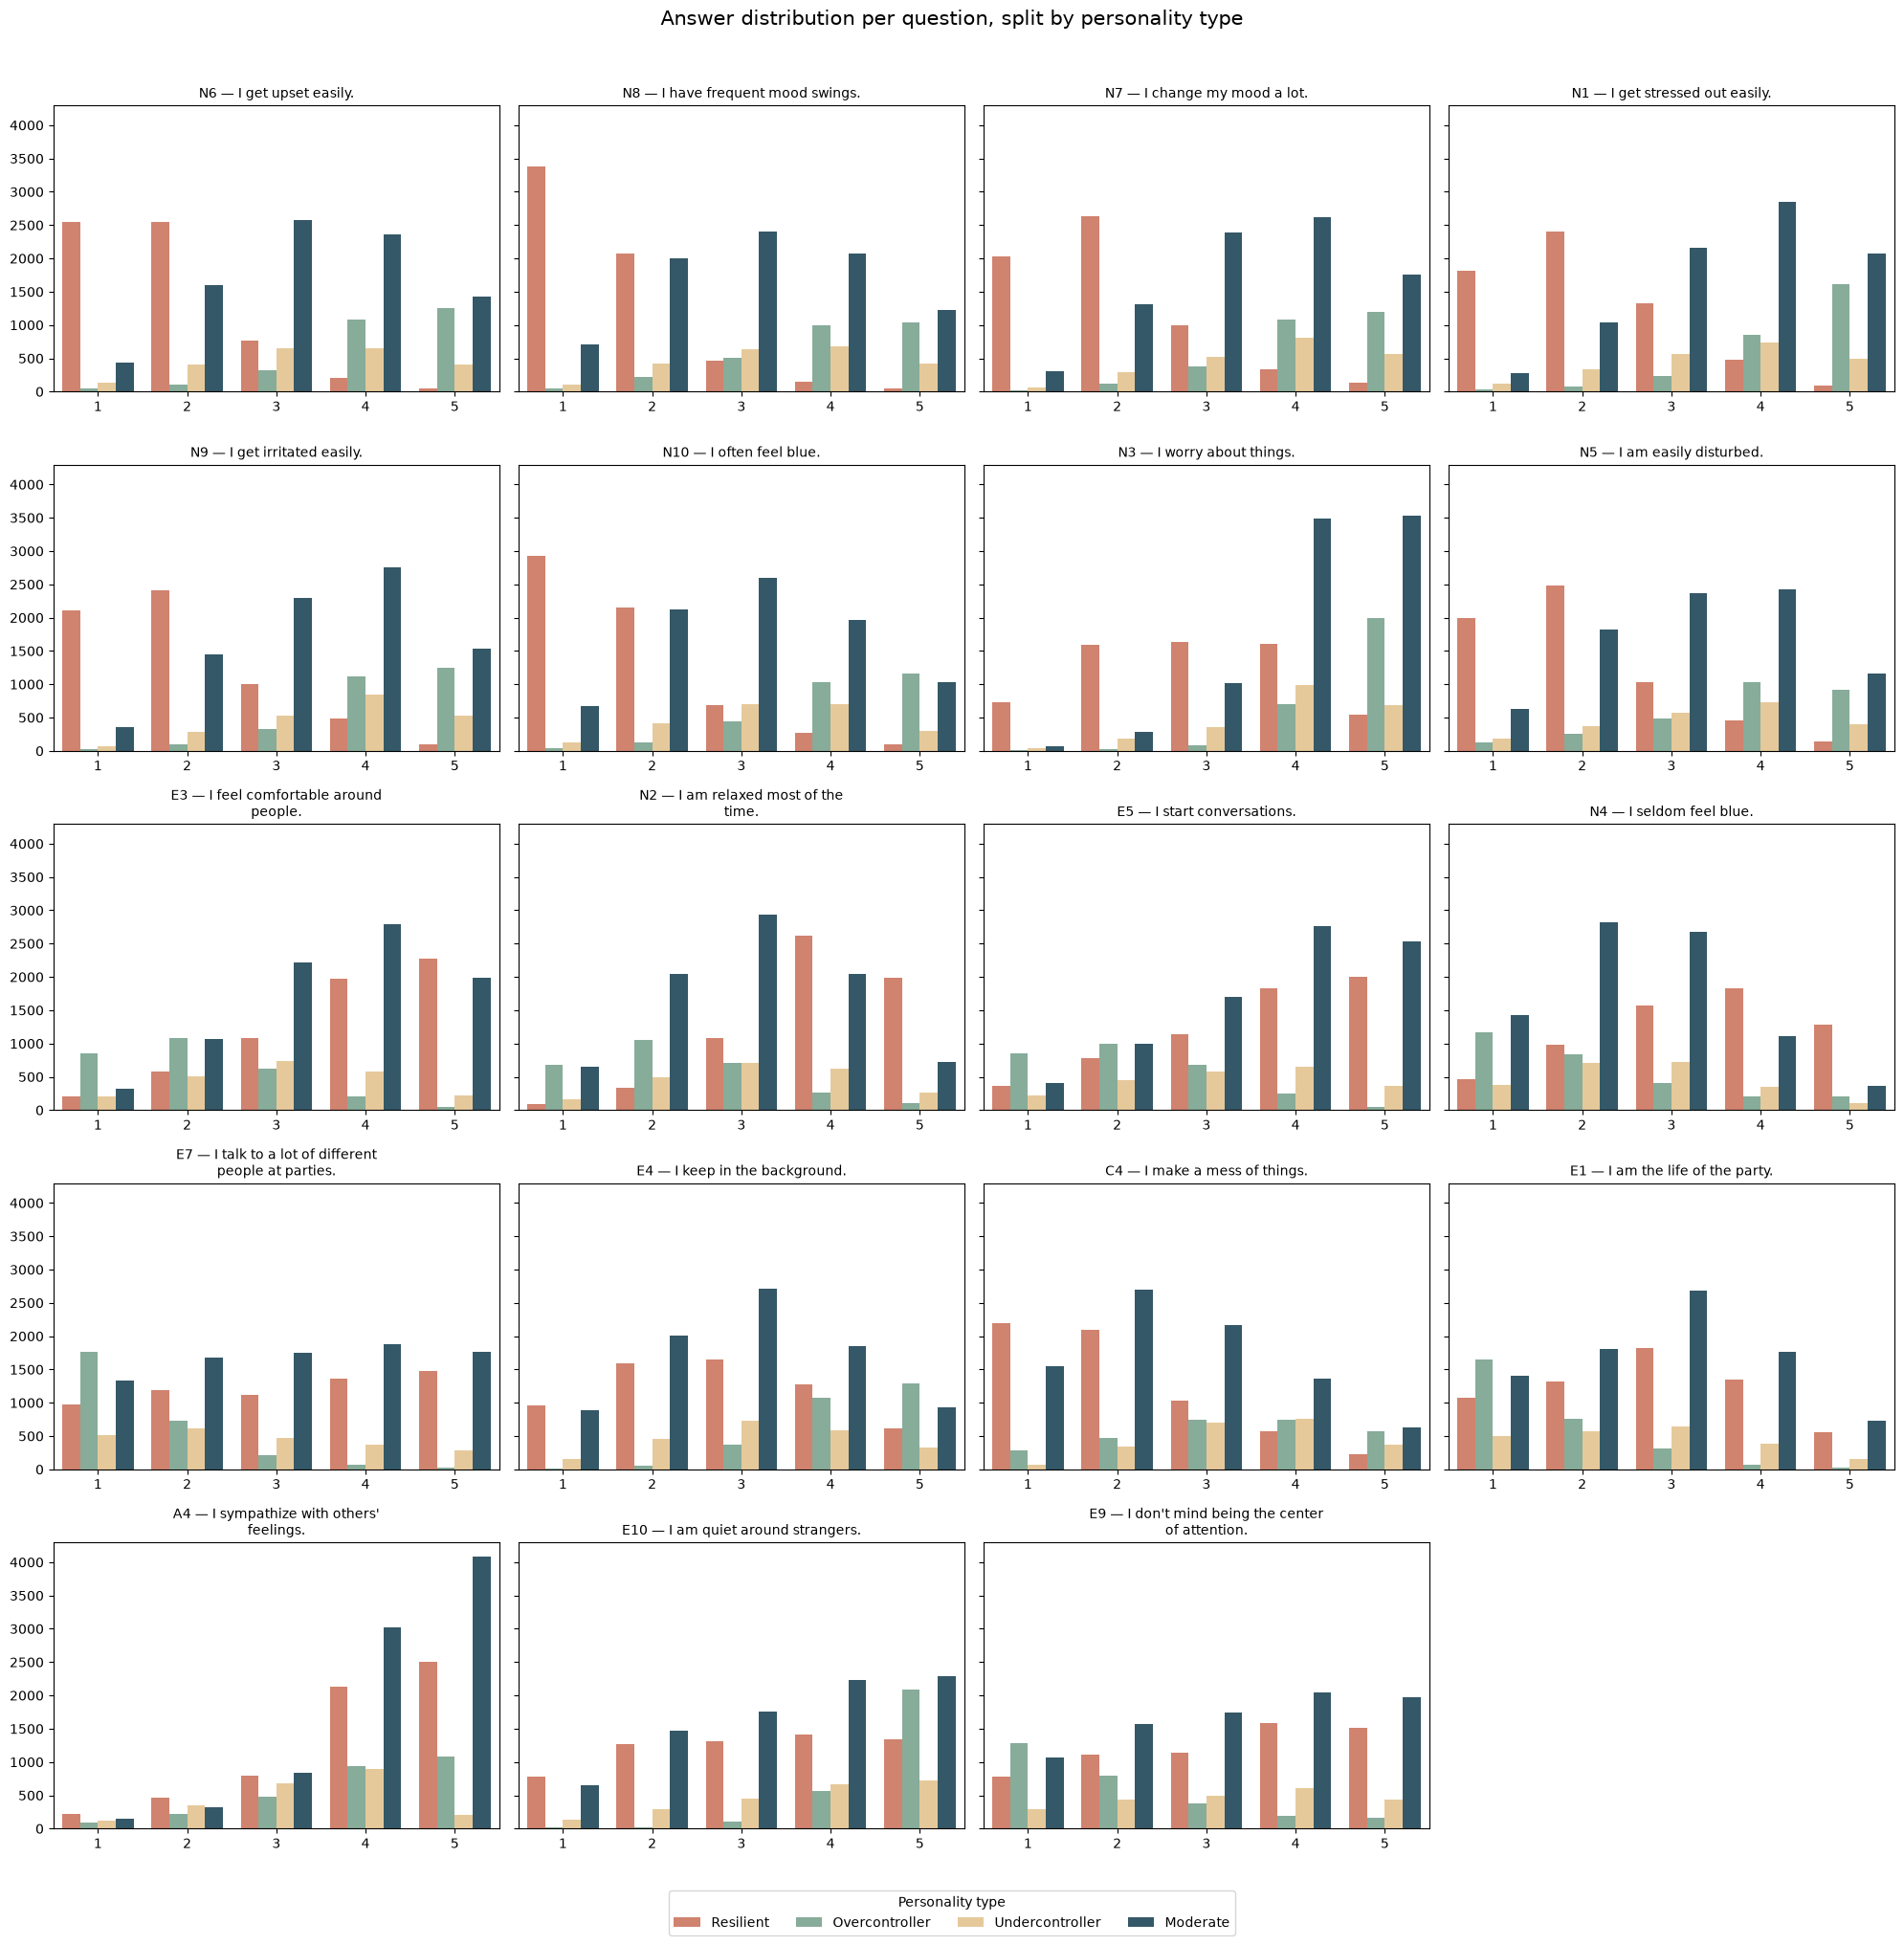

In [14]:
item_labels = {
    "N1":  "I get stressed out easily.",
    "N2":  "I am relaxed most of the time.",
    "N3":  "I worry about things.",
    "N4":  "I seldom feel blue.",
    "N5":  "I am easily disturbed.",
    "N6":  "I get upset easily.",
    "N7":  "I change my mood a lot.",
    "N8":  "I have frequent mood swings.",
    "N9":  "I get irritated easily.",
    "N10": "I often feel blue.",
    "E1":  "I am the life of the party.",
    "E3":  "I feel comfortable around people.",
    "E4":  "I keep in the background.",
    "E5":  "I start conversations.",
    "E7":  "I talk to a lot of different people at parties.",
    "E9":  "I don't mind being the center of attention.",
    "E10": "I am quiet around strangers.",
    "C4":  "I make a mess of things.",
    "A4":  "I sympathize with others' feelings.",
}

target_order = [
    target for target in TARGET_COLORS
    if target in df_clean["target"].dropna().unique()
]

# Plot layout: 4 plots per row
n = len(item_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(20, 4 * nrows),
    sharey=True
)

for i, (ax, col) in enumerate(zip(axes.flat, item_cols)):
    sns.countplot(
        data=df_clean,
        x=col,
        hue="target",
        hue_order=target_order,
        palette=TARGET_COLORS,
        ax=ax,
        legend=(i == 0)
    )

    title = f"{col} — {item_labels.get(col, '')}"
    ax.set_title(
        "\n".join(textwrap.wrap(title, 34)),
        fontsize=10
    )
    ax.set_xlabel("")
    ax.set_ylabel("")

# Remove the empty plots in the last row
for ax in axes.flat[n:]:
    ax.remove()

# One shared legend for all plots
handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[0].get_legend().remove()

fig.legend(
    handles,
    labels,
    title="Personality type",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=4
)

fig.suptitle(
    "Answer distribution per question, split by personality type",
    fontsize=15,
    y=1.0
)

plt.tight_layout(rect=[0, 0.03, 1, 0.985])
plt.show()

**Interpretation:**

- **Neuroticism questions (N1–N10):** Resilient people mostly answer 1–2, Overcontrollers mostly
  4–5. These ten questions are the strongest separators in the data.
- **Extraversion questions (E…):** Overcontrollers cluster at "disagree" on the social statements
  (E1, E5, E7, E9) and at "agree" on "I keep in the background" (E4) and "I am quiet around
  strangers" (E10).
- **C4 and A4** are the only two questions where Undercontrollers look different: more of them agree
  with "I make a mess of things", and fewer of them fully agree with "I sympathize with others'
  feelings".

### 5.2 How the answers are spread

The share of people giving each answer (1–5), per question.

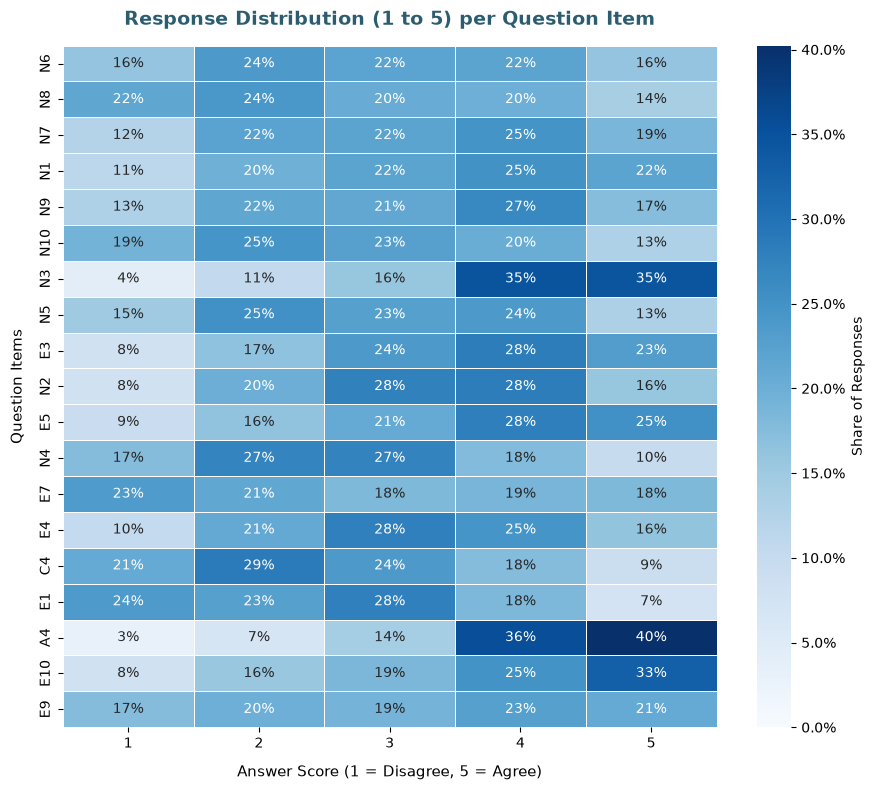

In [15]:
# Percentage share of answers (1–5) per question item
answer_share = (
    df_clean[item_cols]
    .apply(lambda col: col.value_counts(normalize=True))
    .reindex([1, 2, 3, 4, 5])
    .T
)

plt.figure(figsize=(9, 8))

max_share = answer_share.to_numpy().max()

sns.heatmap(
    answer_share,
    annot=True,
    fmt=".0%",
    cmap=THEME["palette"],
    vmin=0,
    vmax=max_share,
    linewidths=0.5,
    cbar_kws={
        "label": "Share of Responses",
        "format": mtick.PercentFormatter(xmax=1)
    }
)

plt.title(
    "Response Distribution (1 to 5) per Question Item",
    fontsize=14,
    pad=15,
    color=THEME["primary"],
    weight="bold"
)
plt.xlabel("Answer Score (1 = Disagree, 5 = Agree)", fontsize=11, labelpad=10)
plt.ylabel("Question Items", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()

**Interpretation:** every answer option is used for every question, so no question is dead weight.
Some questions lean clearly to one side: most people agree with "I sympathize with others' feelings"
(A4) and "I worry about things" (N3), while "I am the life of the party" (E1) and "I make a mess of
things" (C4) lean towards disagree.

### 5.3 Which OCEAN traits the 19 questions cover

The first letter of a column name tells us which of the five OCEAN traits the question belongs to:
**O**penness, **C**onscientiousness, **E**xtraversion, **A**greeableness and **N**euroticism.

In [16]:
# Number of questions per OCEAN trait (Openness has none in this short version)
table_html = (
    pd.Series([c[0] for c in item_cols])
    .map(TRAITS)
    .value_counts()
    .reindex(ocean_order, fill_value=0)
    .to_frame("Count")
    .to_html(classes="table table-striped table-hover", border=0)
)

display(
    HTML(
        f"<h4 style='margin:16px 0 8px; color:{THEME['primary']};'>Question Items per OCEAN Dimension</h4>"
    )
)
display(HTML(table_html))

,Count
Openness to Experience,0
Conscientiousness,1
Extraversion,7
Agreeableness,1
Neuroticism,10


**Interpretation:** the 19 questions are not spread evenly. Ten measure Neuroticism and seven
Extraversion, but Conscientiousness and Agreeableness have **only one question each** (C4, A4), and
Openness has none. The Undercontroller type is defined by low Conscientiousness **and** low
Agreeableness, so most of the information needed to recognise it was lost when the original
50-question test was shortened to 19. This is why Undercontroller is the hardest type for every model
in `modeling.ipynb`.

### 5.4 Correlations between the questions

Pearson correlation between all numeric columns (the 19 questions and `age`): +1 means two
questions are always answered the same way, −1 means always the opposite way, 0 means no relation.

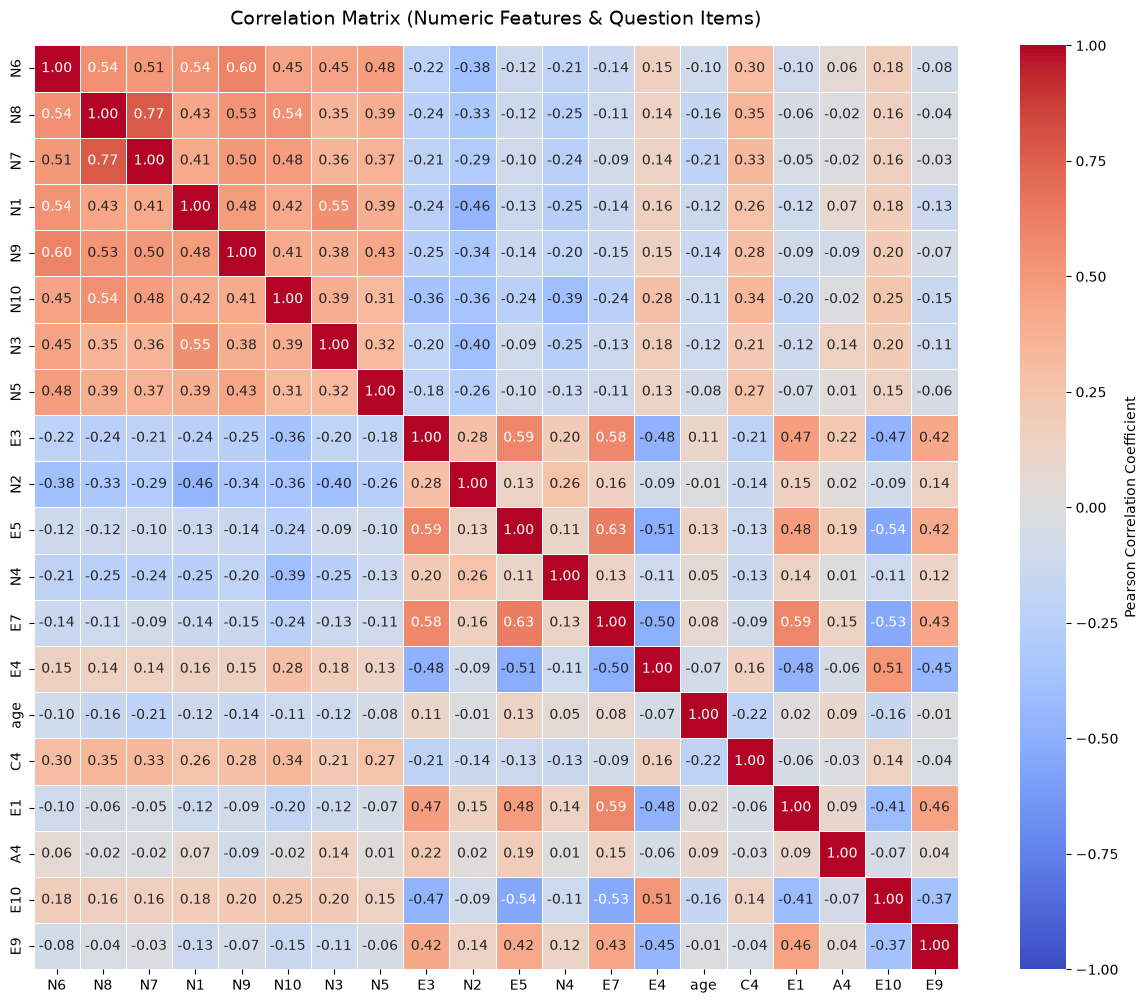

In [17]:
# All numeric columns: the 19 questions and age
numeric_df = df_clean.select_dtypes(include=[np.number])

# Compute correlation matrix
corr = numeric_df.corr()

# 1. Heatmap of all correlations
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    cmap="coolwarm", 
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation Coefficient"}
)
plt.title("Correlation Matrix (Numeric Features & Question Items)", fontsize=14, pad=15)
plt.show()

# 2. Every pair only once: keep the upper triangle, without the diagonal (a column with itself)
upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper_tri.unstack().dropna()

top_pos = (
    pairs.sort_values(ascending=False)
    .head(5)
    .round(2)
    .to_frame("Correlation")
    .to_html(classes="table table-hover")
)

top_neg = (
    pairs.sort_values(ascending=True)
    .head(5)
    .round(2)
    .to_frame("Correlation")
    .to_html(classes="table table-hover")
)

# 3. The 5 strongest positive and negative pairs, side by side
html = f"""
<div style="display:flex; gap:30px; align-items:flex-start; margin-top:10px;">
    <div style="min-width:240px; padding:14px; background:#f8fafc; border:1px solid #d9e2ec; 
                border-top:4px solid {THEME['success_border']}; border-radius:6px;">
        <h4 style="margin:0 0 10px 0; color:{THEME['primary']}; font-weight:700;">
            Strongest Positive Pairs
        </h4>
        {top_pos}
    </div>
    <div style="min-width:240px; padding:14px; background:#f8fafc; border:1px solid #d9e2ec; 
                border-top:4px solid {THEME['danger_border']}; border-radius:6px;">
        <h4 style="margin:0 0 10px 0; color:{THEME['primary']}; font-weight:700;">
            Strongest Negative Pairs
        </h4>
        {top_neg}
    </div>
</div>
"""

display(HTML(html))

**Interpretation:**

- **Strongest positive pairs:** "I change my mood a lot" and "I have frequent mood swings" (N7–N8,
  r = 0.77) ask almost the same thing. Social statements go together too, for example "I start
  conversations" and "I talk to a lot of different people at parties" (E5–E7, 0.63).
- **Strongest negative pairs** are all reverse-worded Extraversion statements, for example "I am
  quiet around strangers" vs. "I start conversations" (E10–E5, −0.54). That is expected: the
  statements are worded in opposite directions. The models learn the direction by themselves, so the
  answers do **not** need to be flipped.
- The Neuroticism and Extraversion questions form two tight blocks, which matches the two traits that
  drive most of the personality types.
- **Age** correlates only weakly with every question (at most |r| ≈ 0.22).

### 5.5 Age, gender and hand per personality type

Top: the age distribution per type. Bottom: gender and writing hand per type.

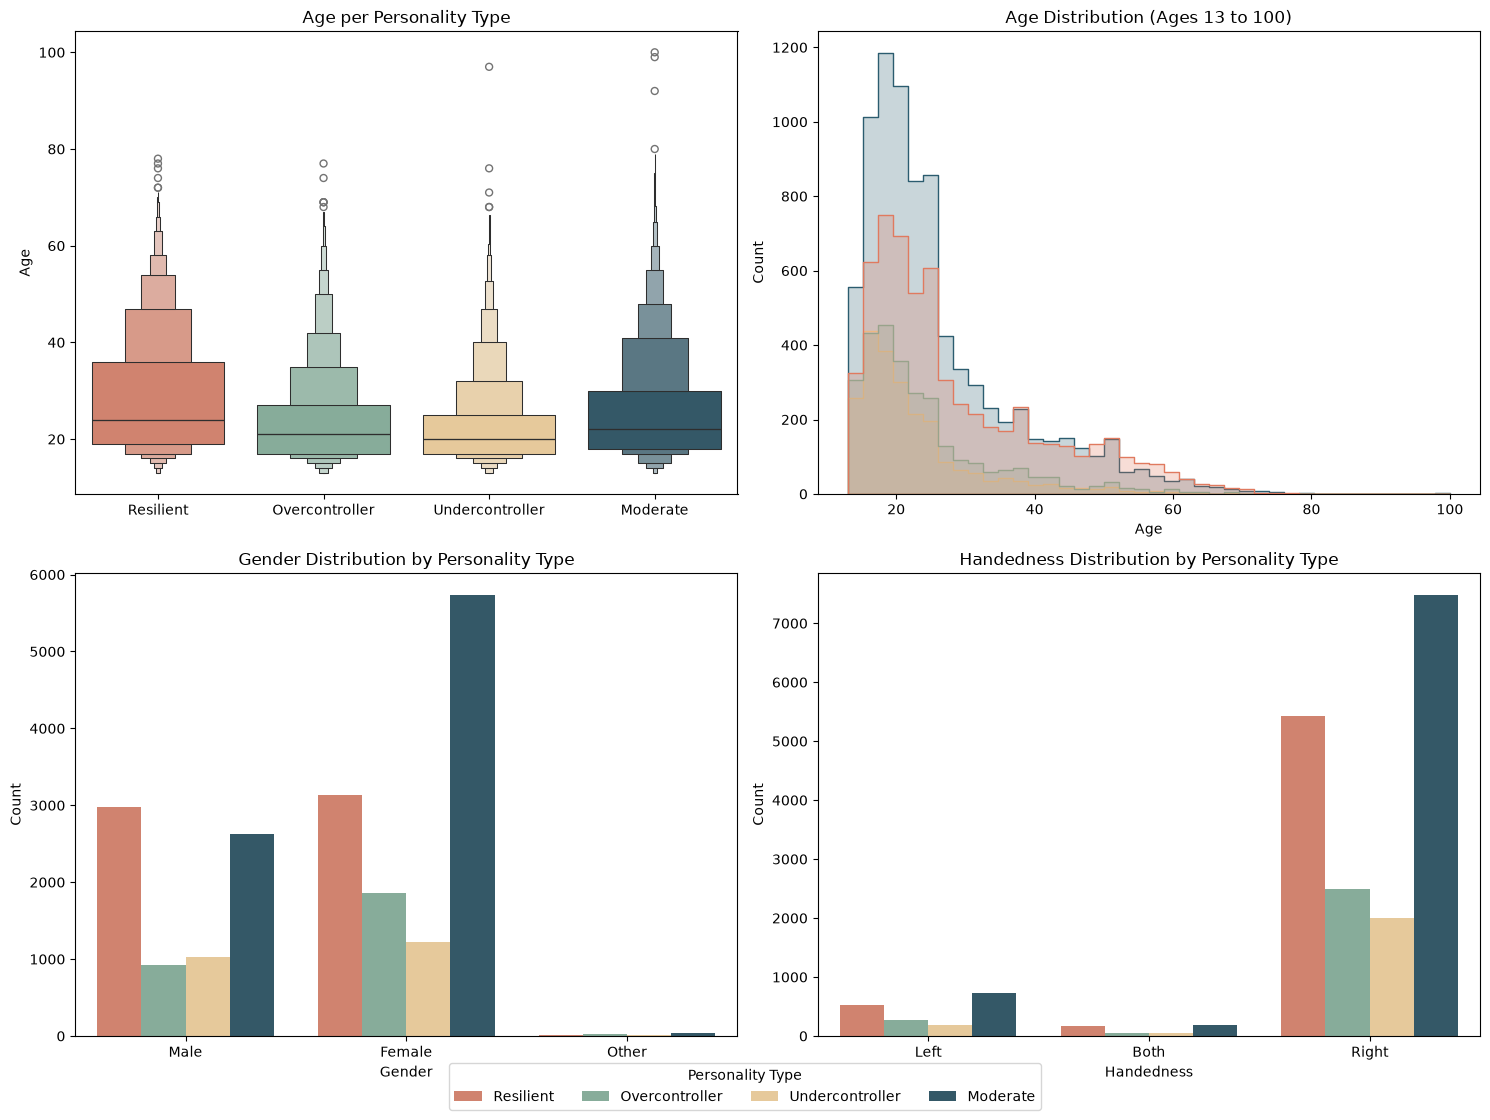

In [18]:
# Only the personality types that exist in the cleaned data, in the fixed colour order
target_order = [t for t in TARGET_COLORS.keys() if t in df_clean["target"].unique()]

min_age = int(df_clean["age"].min())
max_age = int(df_clean["age"].max())

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 11))

# 1. Top Left: Age distribution per personality type
sns.boxenplot(
    data=df_clean,
    x="target",
    y="age",
    order=target_order,
    palette=TARGET_COLORS,
    hue="target",
    legend=False,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Age per Personality Type")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Age")

# 2. Top Right: Age histogram by target
sns.histplot(
    data=df_clean,
    x="age",
    hue="target",
    hue_order=target_order,
    palette=TARGET_COLORS,
    bins=40,
    element="step",
    legend=False,
    ax=axes[0, 1]
)
axes[0, 1].set_title(f"Age Distribution (Ages {min_age} to {max_age})")
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Count")

# 3. Bottom Left: Gender distribution
sns.countplot(
    data=df_clean,
    x="gender",
    hue="target",
    hue_order=target_order,
    palette=TARGET_COLORS,
    legend=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Gender Distribution by Personality Type")
axes[1, 0].set_xlabel("Gender")
axes[1, 0].set_ylabel("Count")

# 4. Bottom right: writing hand, ordered Left, Both, Right
sns.countplot(
    data=df_clean,
    x="hand",
    order=["Left", "Both", "Right"],
    hue="target",
    hue_order=target_order,
    palette=TARGET_COLORS,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Handedness Distribution by Personality Type")
axes[1, 1].set_xlabel("Handedness")
axes[1, 1].set_ylabel("Count")

# One shared legend, centred below the figure
handles, labels = axes[1, 1].get_legend_handles_labels()
axes[1, 1].get_legend().remove()

fig.legend(
    handles=handles,
    labels=labels,
    title="Personality Type",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=len(target_order),
    frameon=True
)

plt.tight_layout()
plt.show()

**Interpretation:**

- **Age is strongly skewed towards young people:** 73% are under 30 and the median age is 22.
  Resilient people are slightly older (median 24, middle half between 19 and 36), Undercontrollers
  slightly younger (median 20, middle half between 17 and 25). The distributions overlap heavily,
  so **age alone barely separates the types**. The signal comes from the questionnaire answers.
- **Gender shows real differences:** 39% of men are Resilient compared with 26% of women, and women
  are more often Moderate (48% vs. 35%). The small "Other" group (about 100 people) is more often
  Overcontroller (33%).
- **Writing hand hardly matters:** the shares of the four types are almost the same for left-handed,
  right-handed and two-handed people. It stays in the data because the project brief asks for it as
  an input in the app.

## 6. Key findings and what they mean for the modeling

- **Size:** 19,719 people and 23 columns: 19 question scores, `age`, `gender`, `hand` and `target`.
  After cleaning, **19,588 rows** remain (0.66% removed), saved as `data/data_clean.csv`.
- **Imbalanced classes:** Moderate ≈ 43%, Resilient ≈ 31%, Overcontroller ≈ 14%, Undercontroller ≈ 12%.
  → `modeling.ipynb` compares models with **macro F1** and tests `class_weight="balanced"`, which
  gives the small types more weight.
- **The questions carry clear signal:** the Neuroticism questions separate Resilient (low answers)
  from Overcontroller (high answers), and the Extraversion questions separate Overcontroller from the rest.
- **Undercontroller will be the hardest type:** it is defined by Conscientiousness and Agreeableness,
  but only one question each (C4, A4) measures these traits.
- **Invalid answers:** one row had `0` in every question (outside the 1–5 scale) and was removed.
- **Age:** 83 impossible values above 100. 73 were birth years and were converted into ages
  (assumed survey year 2017), and 10 that could not be fixed were removed. Age itself carries little signal.
- **Missing values:** `gender` (24) and `hand` (100), 120 rows in total, were removed. The imputer in
  the modeling pipeline still covers the app.
- **Identical answers and duplicates** (about 0.1% of the rows) were kept.
- **Gender** shows some differences between the types (more Resilient among men), **hand** hardly any.

**In the Streamlit app** the inputs are restricted (answer buttons 1–5, age 13–100, gender and hand
as fixed choices), so a user cannot enter the kinds of values we had to clean here.

**Next step:** `modeling.ipynb` reads `data/data_clean.csv`, builds the preprocessing pipeline and
compares four models.